In [26]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import joblib
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn import metrics
from sklearn.neighbors import KNeighborsRegressor
from sklearn import tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [27]:
MODEL_PATH = 'lapdata.pkl'
SPLITS_DIR = 'splits'
X_TRAIN_PATH = os.path.join(SPLITS_DIR, 'X_train.csv')
Y_TRAIN_PATH = os.path.join(SPLITS_DIR, 'y_train.csv')
X_TEST_PATH = os.path.join(SPLITS_DIR, 'X_test.csv')
Y_TEST_PATH = os.path.join(SPLITS_DIR, 'y_test.csv')

In [28]:
try:
    pipeline = joblib.load(MODEL_PATH)
    print(f"Trained pipeline loaded successfully from: {MODEL_PATH}")
    print(f"Type of loaded object: {type(pipeline)}")
    if not isinstance(pipeline, Pipeline):
        raise TypeError("Loaded object is not a scikit-learn Pipeline. Check your saving process.")
except (FileNotFoundError, TypeError) as e:
    print(f"ERROR: Failed to load pipeline. {e}")
    print("Please ensure the model is correctly saved and the path is accurate.")
    # Exit or raise an error to prevent further execution without a valid pipeline
    exit() # Exits the script if loading fails

X_train, y_train, X_test, y_test = None, None, None, None # Initialize to None


Trained pipeline loaded successfully from: lapdata.pkl
Type of loaded object: <class 'sklearn.pipeline.Pipeline'>


In [29]:
try:
    X_train = pd.read_csv(X_TRAIN_PATH)
    y_train = pd.read_csv(Y_TRAIN_PATH).squeeze() # .squeeze() ensures 1D Series
    X_test = pd.read_csv(X_TEST_PATH)
    y_test = pd.read_csv(Y_TEST_PATH).squeeze() # .squeeze() ensures 1D Series
    print("Training and Test data loaded successfully.")
except FileNotFoundError as e:
    print(f"ERROR: Failed to load data splits. {e}")
    print("Please ensure X_train.csv, y_train.csv, X_test.csv, y_test.csv are in the 'splits/' directory.")
    # Exit or raise an error to prevent further execution
    exit() # Exits the script if loading fails


Training and Test data loaded successfully.



--- Model Evaluation on Training Set (Log Scale) ---
R2 Score: 0.8885
Mean Absolute Error (MAE): 0.1563
Mean Squared Error (MSE): 0.0428
Root Mean Squared Error (RMSE): 0.2068
Mean Absolute Percentage Error (MAPE): 0.0144
Skewness of residuals: 0.22
Kurtosis of residuals (Excess + 3): 5.46


C:\ProgramData\miniforge3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


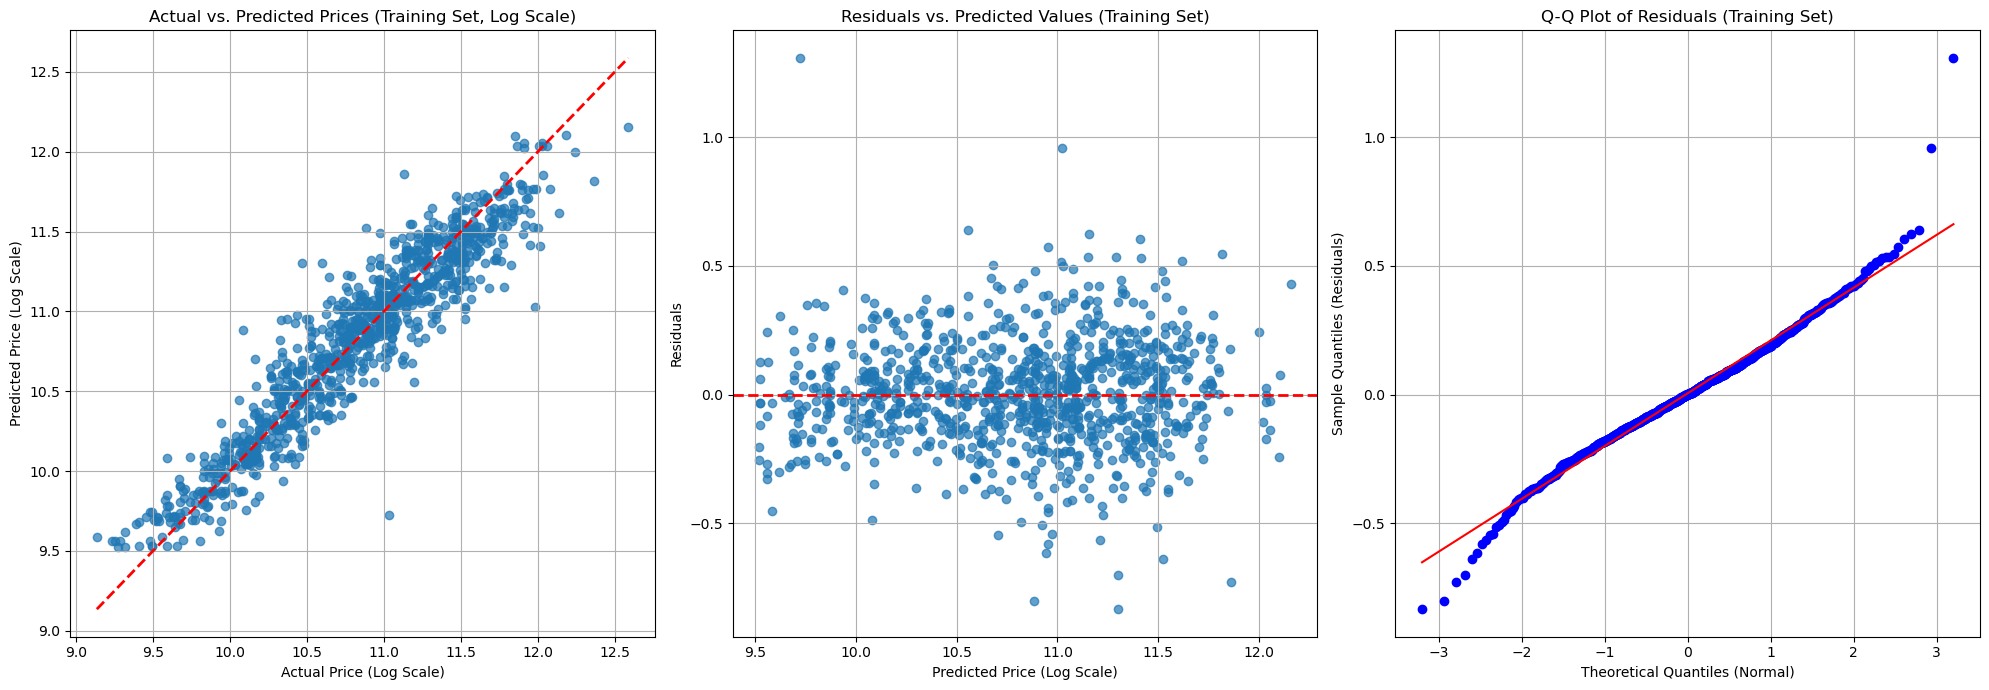

In [30]:
def evaluate_model_performance(model, X_data, y_true, dataset_name=""):
   
    print(f"\n--- Model Evaluation on {dataset_name} Set (Log Scale) ---")

    y_pred = model.predict(X_data)

    # Calculate Metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"R2 Score: {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

    # MAPE (handle potential division by zero if y_true can be zero on log scale, e.g., if price was 1)
    try:
        mape = mean_absolute_percentage_error(y_true, y_pred)
        print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")
    except ValueError as e:
        print(f"Warning: Could not calculate MAPE - {e}")

    # Residuals
    residuals = y_true - y_pred
    print(f"Skewness of residuals: {np.round(residuals.skew(), 2)}")
    print(f"Kurtosis of residuals (Excess + 3): {np.round(residuals.kurt() + 3, 2)}")

    # Visualizations
    plt.figure(figsize=(20, 7))

    # Plot 1: Actual vs. Predicted
    plt.subplot(1, 3, 1)
    plt.scatter(y_true, y_pred, alpha=0.7)
    max_val = max(y_true.max(), y_pred.max())
    min_val = min(y_true.min(), y_pred.min())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    plt.title(f"Actual vs. Predicted Prices ({dataset_name} Set, Log Scale)")
    plt.xlabel("Actual Price (Log Scale)")
    plt.ylabel("Predicted Price (Log Scale)")
    plt.grid(True)

    # Plot 2: Residuals vs. Predicted
    plt.subplot(1, 3, 2)
    plt.scatter(y_pred, residuals, alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.title(f"Residuals vs. Predicted Values ({dataset_name} Set)")
    plt.xlabel("Predicted Price (Log Scale)")
    plt.ylabel("Residuals")
    plt.grid(True)

    # Plot 3: Q-Q Plot of Residuals
    plt.subplot(1, 3, 3)
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of Residuals ({dataset_name} Set)")
    plt.xlabel("Theoretical Quantiles (Normal)")
    plt.ylabel("Sample Quantiles (Residuals)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()
if pipeline is not None:
    evaluate_model_performance(pipeline, X_train, y_train, dataset_name="Training")
